In [4]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data_dir = Path("data/optuna_regional_gee_configs")
TARGET_REGION = "DES"

trials_json_path = data_dir / f"{TARGET_REGION}_all_trials.json"
assert trials_json_path.exists(), f"File not found: {trials_json_path}"

with open(trials_json_path, "r") as f:
    trials_raw = json.load(f)

# Convert tabular attributes to DataFrame (keeping full JSON for band lists)
df_all = pd.DataFrame([{k: v for k, v in t.items() if k != "selected_bands"} for t in trials_raw])
trials_by_number = {t["trial_number"]: t for t in trials_raw}

# Filter to Pareto-optimal trials and sort by complexity
df_pareto = df_all[df_all["is_pareto"]].sort_values("model_complexity").copy().reset_index(drop=True)

print(f"Loaded {len(df_all)} total trials for Region '{TARGET_REGION}'.")
print(f"Found {len(df_pareto)} non-dominated Pareto frontier candidates.")

Loaded 40 total trials for Region 'DES'.
Found 7 non-dominated Pareto frontier candidates.


In [5]:
display_cols = [
    "trial_number", "macro_f1", "model_complexity", "total_samples",
    "num_input_features", "numberOfTrees", "minLeafPopulation",
    "train_fraction", "feature_strategy", "sampling_strategy"
]

print("=== Pareto Frontier Candidates ===")
with pd.option_context('display.max_columns', None, 'display.width', 1000):
    print(df_pareto[display_cols].to_string(index=False))

=== Pareto Frontier Candidates ===
 trial_number  macro_f1  model_complexity  total_samples  num_input_features  numberOfTrees  minLeafPopulation  train_fraction feature_strategy sampling_strategy
           15  0.942111      8.045195e+10          75101                  10            125                 11             0.2              all        stratified
           21  0.942778      4.053101e+11         150215                  36             50                 12             0.4     uncorrelated        stratified
           30  0.960577      4.734743e+11          75101                  36             75                  2             0.2     uncorrelated        stratified
            1  0.977160      5.036709e+11         150215                  14            100                  4             0.4              all        stratified
           27  0.981507      3.413841e+12         300458                  41             75                  4             0.8              all        stra

In [6]:
# Baseline references
peak_f1 = df_pareto["macro_f1"].max()
min_comp = df_pareto["model_complexity"].min()
max_comp = df_pareto["model_complexity"].max()
min_f1 = df_pareto["macro_f1"].min()

# ----------------------------------------------------
# Strategy A: Epsilon-Tolerance (Within 1.0% of Peak F1)
# ----------------------------------------------------
F1_TOLERANCE = 0.010
viable_eps = df_pareto[df_pareto["macro_f1"] >= (peak_f1 - F1_TOLERANCE)]
trial_strat_a = int(viable_eps.loc[viable_eps["model_complexity"].idxmin()]["trial_number"])

# ----------------------------------------------------
# Strategy B: Normalized Utopia Distance
# ----------------------------------------------------
# Scale both metrics to [0, 1] range
# For F1: 1 is best, so penalty is (peak_f1 - f1) / (peak_f1 - min_f1)
# For Complexity: min is best, so penalty is (comp - min_comp) / (max_comp - min_comp)
f1_penalty = (peak_f1 - df_pareto["macro_f1"]) / (peak_f1 - min_f1)
comp_penalty = (df_pareto["model_complexity"] - min_comp) / (max_comp - min_comp)

df_pareto["utopia_dist"] = np.sqrt(f1_penalty**2 + comp_penalty**2)
trial_strat_b = int(df_pareto.loc[df_pareto["utopia_dist"].idxmin()]["trial_number"])

# ----------------------------------------------------
# Strategy C: Marginal Return Ratio vs Baseline
# ----------------------------------------------------
# Computes (F1 - baseline_F1) / (log10(Comp) - log10(baseline_Comp))
log_comp = np.log10(df_pareto["model_complexity"])
log_base = np.log10(min_comp)
marginal_gain = (df_pareto["macro_f1"] - min_f1) / (log_comp - log_base).replace(0, np.nan)
df_pareto["marginal_return"] = marginal_gain.fillna(0.0)
trial_strat_c = int(df_pareto.loc[df_pareto["marginal_return"].idxmax()]["trial_number"])

# Comparison Table
selection_summary = []
for strat_name, t_num in [
    (f"Strategy A: Min Complexity (F1 drop <= {F1_TOLERANCE:.3f})", trial_strat_a),
    ("Strategy B: Normalized Utopia Distance", trial_strat_b),
    ("Strategy C: Max Marginal Return per Log-Complexity", trial_strat_c),
    ("Baseline: Absolute Peak F1 (Unconstrained)", int(df_pareto.loc[df_pareto["macro_f1"].idxmax()]["trial_number"]))
]:
    t_row = df_pareto[df_pareto["trial_number"] == t_num].iloc[0]
    selection_summary.append({
        "Strategy": strat_name,
        "Trial": int(t_num),
        "Macro-F1": t_row["macro_f1"],
        "F1 Delta vs Peak": t_row["macro_f1"] - peak_f1,
        "Complexity": t_row["model_complexity"],
        "Complexity Reduction vs Peak": f"{max_comp / t_row['model_complexity']:.1f}x smaller",
        "Trees": int(t_row["numberOfTrees"]),
        "MinLeaf": int(t_row["minLeafPopulation"]),
        "Features": int(t_row["num_input_features"]),
        "Samples": int(t_row["total_samples"])
    })

df_selection_summary = pd.DataFrame(selection_summary)
print("\n=== Multi-Criteria Selection Comparison ===")
with pd.option_context('display.max_columns', None, 'display.width', 1000):
    print(df_selection_summary.to_string(index=False))


=== Multi-Criteria Selection Comparison ===
                                          Strategy  Trial  Macro-F1  F1 Delta vs Peak   Complexity Complexity Reduction vs Peak  Trees  MinLeaf  Features  Samples
     Strategy A: Min Complexity (F1 drop <= 0.010)     27  0.981507         -0.006135 3.413841e+12                 4.0x smaller     75        4        41   300458
            Strategy B: Normalized Utopia Distance      1  0.977160         -0.010482 5.036709e+11                27.2x smaller    100        4        14   150215
Strategy C: Max Marginal Return per Log-Complexity      1  0.977160         -0.010482 5.036709e+11                27.2x smaller    100        4        14   150215
        Baseline: Absolute Peak F1 (Unconstrained)     16  0.987642          0.000000 1.368464e+13                 1.0x smaller    150        2        36   375603


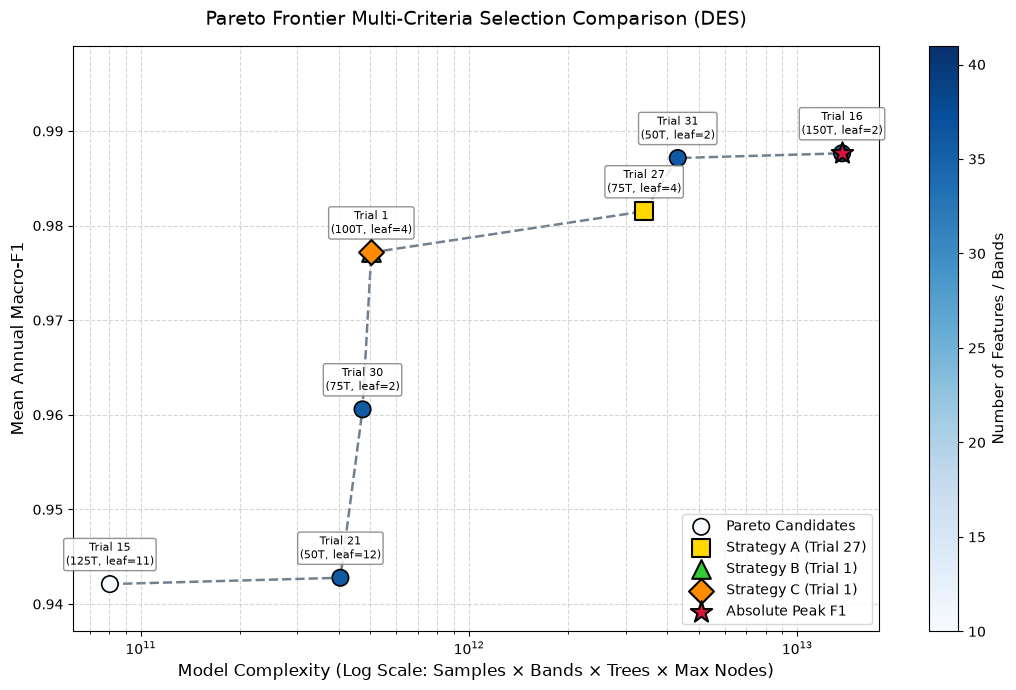

Selection visual saved -> data/optuna_regional_gee_configs/DES_selection_comparison.png


In [8]:
plt.figure(figsize=(11, 7))

# 1. Draw Pareto line
plt.plot(
    df_pareto["model_complexity"],
    df_pareto["macro_f1"],
    color="slategray",
    linestyle="--",
    linewidth=1.8,
    zorder=1
)

# 2. Scatter all Pareto candidates
scatter = plt.scatter(
    df_pareto["model_complexity"],
    df_pareto["macro_f1"],
    c=df_pareto["num_input_features"],
    cmap="Blues",
    s=140,
    edgecolor="black",
    linewidth=1.2,
    zorder=2,
    label="Pareto Candidates"
)
cbar = plt.colorbar(scatter)
cbar.set_label("Number of Features / Bands", fontsize=11)

# 3. Mark selected strategy points
marker_styles = {
    f"Strategy A (Trial {trial_strat_a})": (trial_strat_a, "gold", "s", 180),
    f"Strategy B (Trial {trial_strat_b})": (trial_strat_b, "limegreen", "^", 180),
    f"Strategy C (Trial {trial_strat_c})": (trial_strat_c, "darkorange", "D", 160),
    f"Absolute Peak F1": (int(df_pareto.loc[df_pareto['macro_f1'].idxmax()]['trial_number']), "crimson", "*", 260)
}

for label, (t_num, color, marker, sz) in marker_styles.items():
    row = df_pareto[df_pareto["trial_number"] == t_num].iloc[0]
    plt.scatter(
        row["model_complexity"],
        row["macro_f1"],
        color=color,
        marker=marker,
        s=sz,
        edgecolor="black",
        linewidth=1.5,
        zorder=4,
        label=label
    )

# Annotate trial details
for _, row in df_pareto.iterrows():
    plt.annotate(
        f"Trial {int(row['trial_number'])}\n({int(row['numberOfTrees'])}T, leaf={int(row['minLeafPopulation'])})",
        xy=(row["model_complexity"], row["macro_f1"]),
        xytext=(0, 14),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.85)
    )

plt.xscale("log")
plt.title(f"Pareto Frontier Multi-Criteria Selection Comparison ({TARGET_REGION})", fontsize=14, pad=15)
plt.xlabel("Model Complexity (Log Scale: Samples × Bands × Trees × Max Nodes)", fontsize=12)
plt.ylabel("Mean Annual Macro-F1", fontsize=12)
plt.grid(True, which="both", linestyle="--", alpha=0.5)

y_pad = (peak_f1 - min_f1) * 0.25
plt.ylim(min_f1 - 0.005, peak_f1 + y_pad)
plt.legend(loc="lower right", frameon=True, fontsize=10)
plt.tight_layout()

comparison_plot_path = data_dir / f"{TARGET_REGION}_selection_comparison.png"
plt.savefig(comparison_plot_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Selection visual saved -> {comparison_plot_path}")

In [ ]:
# Choose which trial to lock in for GEE production:
# Options: trial_strat_a, trial_strat_b, trial_strat_c, or an explicit int like 1, 27, 31
# CHOSEN_TRIAL_NUMBER = trial_strat_a

# Retrieve the complete raw record including the active band list
final_trial_pkg = trials_by_number[CHOSEN_TRIAL_NUMBER]

# Build Earth Engine deployment config
gee_config = {
    "region": TARGET_REGION,
    "selected_trial_number": int(final_trial_pkg["trial_number"]),
    "selection_strategy": f"epsilon_tolerance_{F1_TOLERANCE}_f1_drop",
    "macro_f1": float(final_trial_pkg["macro_f1"]),
    "model_complexity": float(final_trial_pkg["model_complexity"]),
    "total_samples": int(final_trial_pkg["total_samples"]),
    "train_fraction": float(final_trial_pkg["train_fraction"]),
    "sampling_strategy": str(final_trial_pkg["sampling_strategy"]),
    "feature_strategy": str(final_trial_pkg["feature_strategy"]),
    "numberOfTrees": int(final_trial_pkg["numberOfTrees"]),
    "minLeafPopulation": int(final_trial_pkg["minLeafPopulation"]),
    "variablesPerSplit": int(final_trial_pkg["variablesPerSplit"]),
    "num_input_features": int(final_trial_pkg["num_input_features"]),
    "selected_bands": list(final_trial_pkg["selected_bands"])
}

final_output_path = data_dir / f"{TARGET_REGION}_best_params.json"
with open(final_output_path, "w") as f:
    json.dump(gee_config, f, indent=2)

print(f"\n=======================================================")
print(f"  DEPLOYMENT CONFIG GENERATED FOR REGION: {TARGET_REGION}")
print(f"=======================================================")
print(f"  Selected Trial:         #{gee_config['selected_trial_number']}")
print(f"  Mean Macro-F1:          {gee_config['macro_f1']:.4f}")
print(f"  Model Complexity:       {gee_config['model_complexity']:.2e}")
print(f"  Number of Trees:        {gee_config['numberOfTrees']}")
print(f"  Min Leaf Population:    {gee_config['minLeafPopulation']}")
print(f"  Variables Per Split:    {gee_config['variablesPerSplit']}")
print(f"  Total Feature Count:    {gee_config['num_input_features']}")
print(f"  Active Bands:           {gee_config['selected_bands'][:6]} ... ({len(gee_config['selected_bands'])} total)")
print(f"  Saved To:               {final_output_path}")